
Loading ipo_data.csv...
Loaded 10000 records.
Preprocessing...
Train: 8000, Test: 2000
Training models...

--- K-Means ---
  Cluster 0 (Success): 1092 samples, purity 0.5504
  Cluster 1 (Success): 908 samples, purity 0.5804

--- Logistic Regression ---
  Accuracy: 0.6065  Precision: 0.6215  Recall: 0.7730  F1: 0.6891

--- Random Forest ---
  Accuracy: 0.5955  Precision: 0.6255  Recall: 0.7048  F1: 0.6628

--- Decision Tree ---
  Accuracy: 0.6025  Precision: 0.6213  Recall: 0.7562  F1: 0.6821

=== Enter Future IPO Metadata ===

Company Name (text): AP Inc

Sector (choose one):
  1. Technology
  2. Healthcare
  3. Finance
  4. Energy
  5. Consumer Goods
  6. Industrials
  7. Real Estate
  8. Telecommunications
Enter choice number or name: 3

Offer Price (float, 5.0-200.0): 100

Shares Offered (integer, 100000-50000000): 200000

Underwriter Reputation (integer, 1-10): 8

Market Conditions (choose one):
  1. Bull
  2. Bear
  3. Neutral
Enter choice number or name: 1

Company Revenue (floa

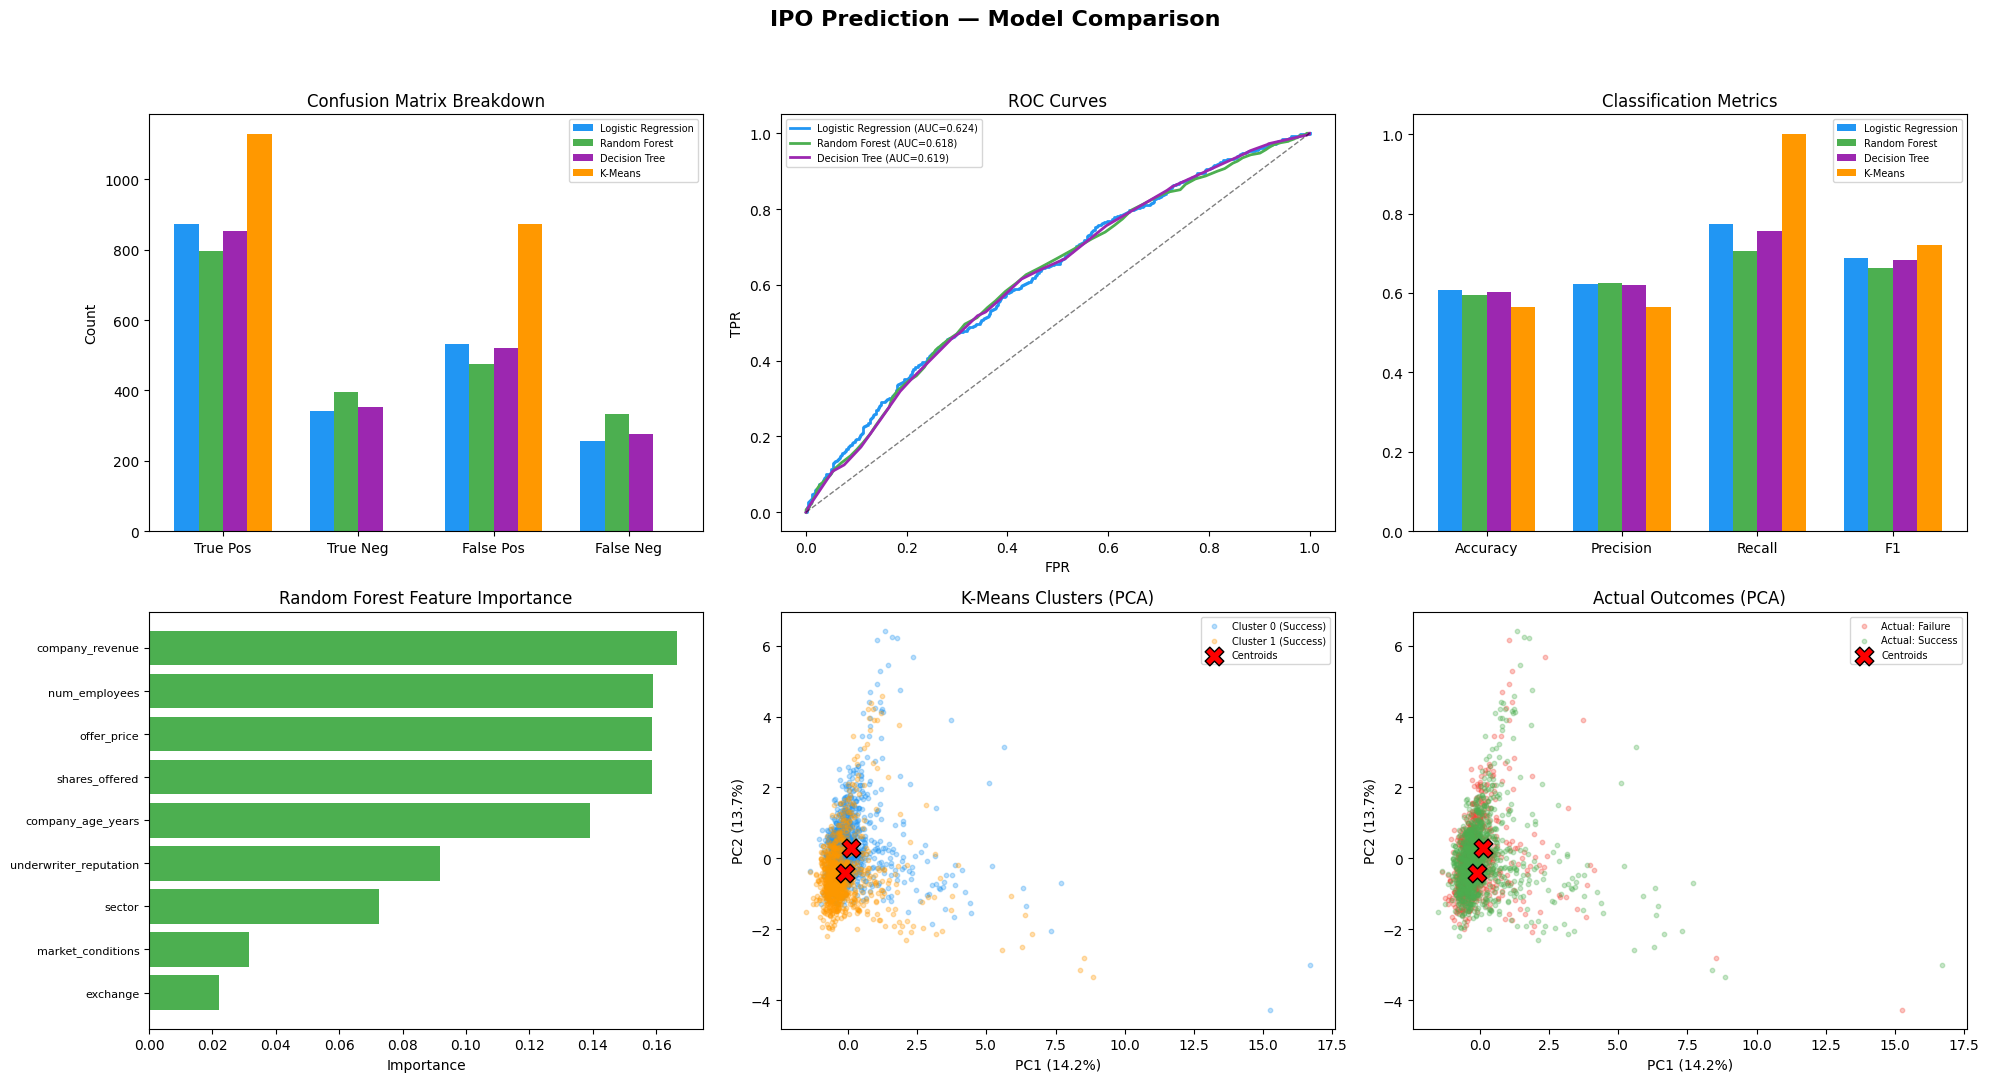

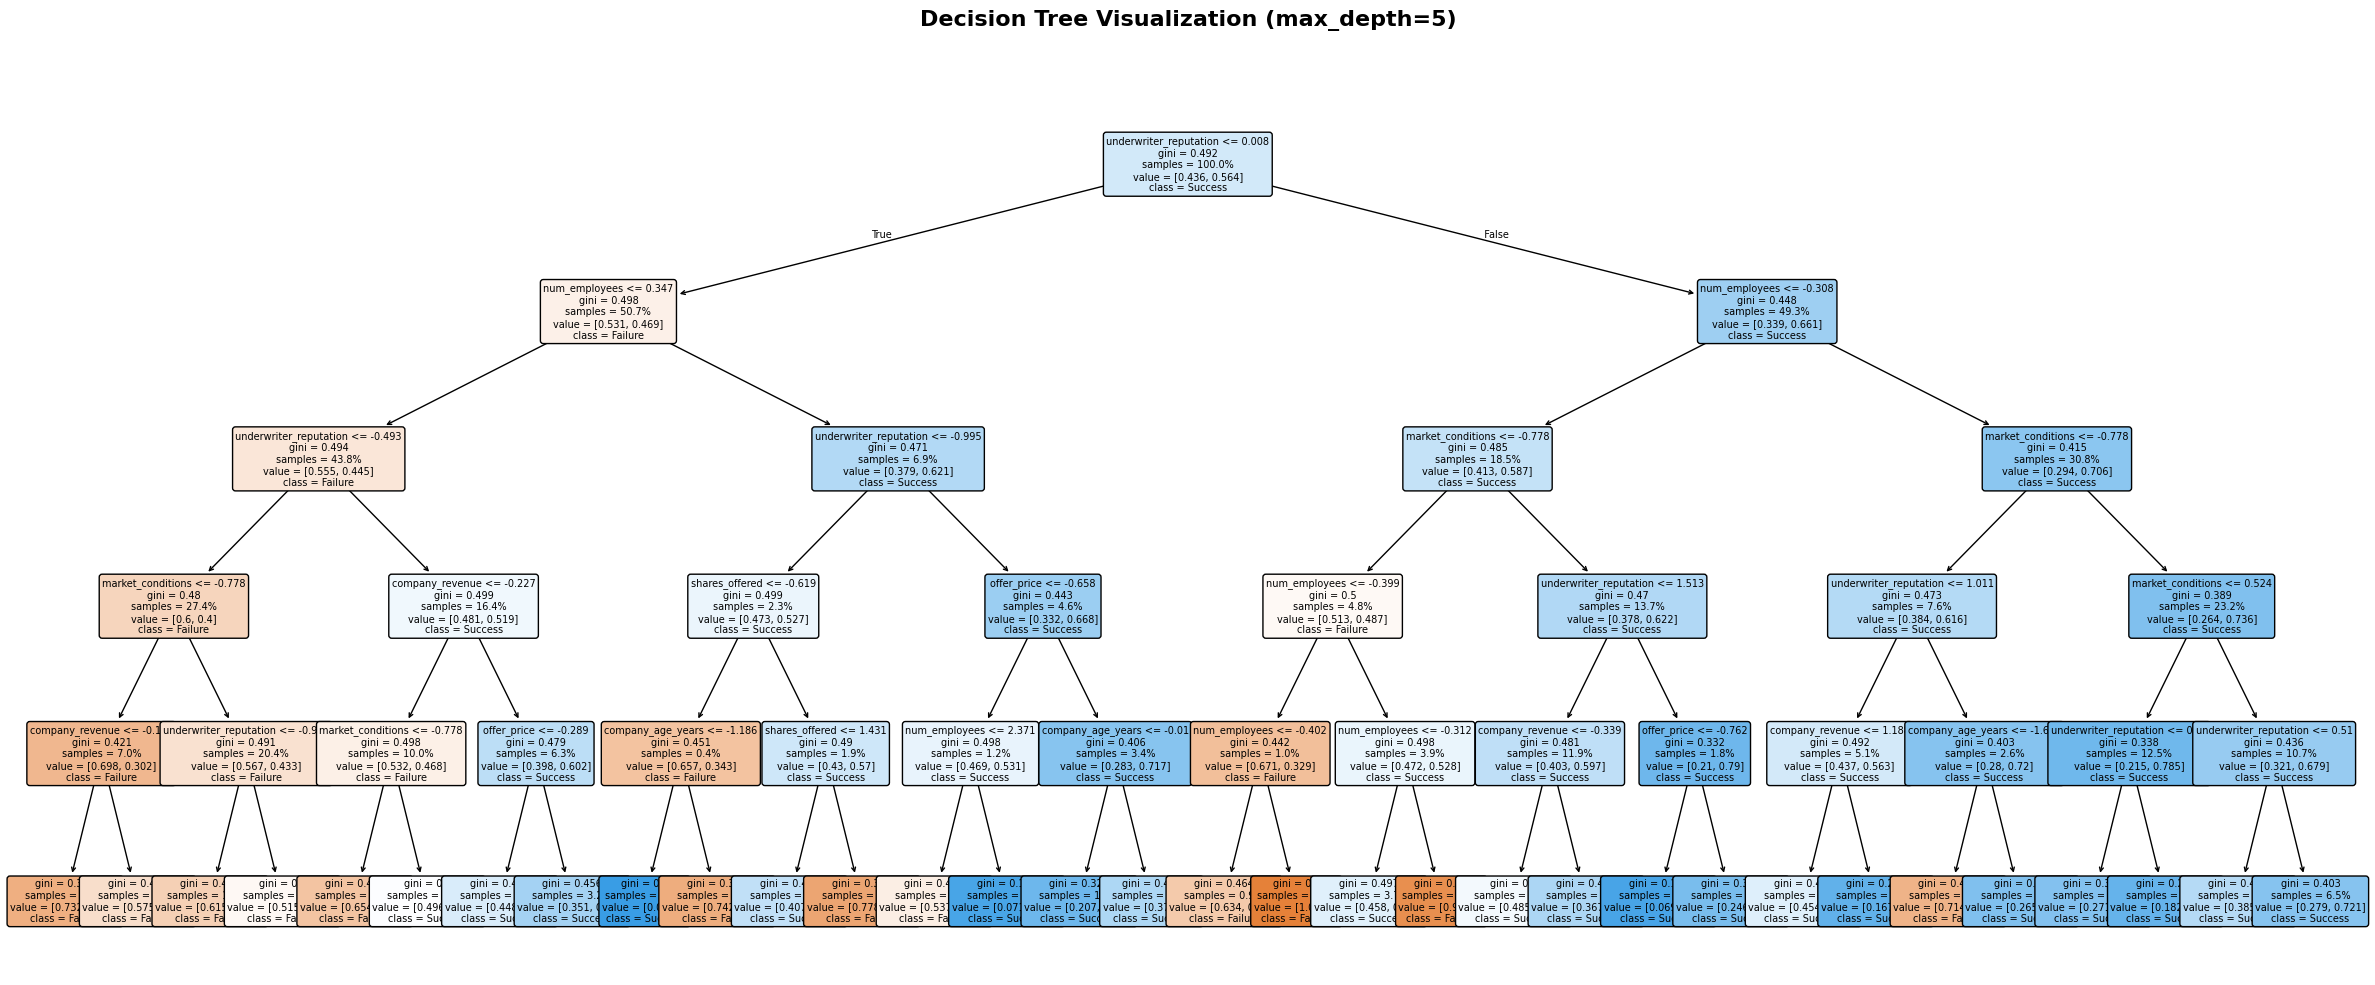

In [1]:


import logging
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

logger = logging.getLogger(__name__)

# Constants

CATEGORICAL_COLUMNS = ["sector", "market_conditions", "exchange"]
TARGET_COLUMN = "ipo_outcome"
DROP_COLUMNS = ["company_name"]
OUTCOME_MAP = {"Success": 1, "Failure": 0}
OUTCOME_MAP_INV = {1: "Success", 0: "Failure"}

IPO_FIELDS = [
    {"name": "company_name", "type": "str", "prompt": "Company Name"},
    {"name": "sector", "type": "choice", "options": [
        "Technology", "Healthcare", "Finance", "Energy",
        "Consumer Goods", "Industrials", "Real Estate", "Telecommunications"]},
    {"name": "offer_price", "type": "float", "range": (5.0, 200.0)},
    {"name": "shares_offered", "type": "int", "range": (100_000, 50_000_000)},
    {"name": "underwriter_reputation", "type": "int", "range": (1, 10)},
    {"name": "market_conditions", "type": "choice", "options": ["Bull", "Bear", "Neutral"]},
    {"name": "company_revenue", "type": "float", "range": (0.1, 10_000.0)},
    {"name": "company_age_years", "type": "int", "range": (1, 80)},
    {"name": "num_employees", "type": "int", "range": (10, 500_000)},
    {"name": "exchange", "type": "choice", "options": ["NYSE", "NASDAQ"]},
]


# ── Data Loading

def load_data(file_path: str) -> pd.DataFrame:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")
    if not os.access(file_path, os.R_OK):
        raise PermissionError(f"Cannot read file '{file_path}'.")
    try:
        df = pd.read_csv(file_path)
    except pd.errors.EmptyDataError:
        raise ValueError(f"File '{file_path}' contains no usable data.")
    if df.empty:
        raise ValueError(f"File '{file_path}' contains no usable data.")
    return df


# ── Preprocessing

class Preprocessor:
    def __init__(self, test_size: float = 0.2, random_state: int = 42):
        self.label_encoders: dict[str, LabelEncoder] = {}
        self.scaler = StandardScaler()
        self.feature_columns: list[str] = []
        self.test_size = test_size
        self.random_state = random_state
        self._fitted = False

    def fit_transform(self, df: pd.DataFrame):
        df = df.copy()
        initial = len(df)
        df = df.dropna()
        dropped = initial - len(df)
        if dropped > 0:
            print(f"  Dropped {dropped} rows with missing values.")
        if len(df) < 10:
            raise ValueError(f"Dataset has only {len(df)} rows. Need at least 10.")

        for col in DROP_COLUMNS:
            if col in df.columns:
                df = df.drop(columns=[col])

        y = df[TARGET_COLUMN].map(OUTCOME_MAP).values
        df = df.drop(columns=[TARGET_COLUMN])

        for col in CATEGORICAL_COLUMNS:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col])
                self.label_encoders[col] = le

        self.feature_columns = list(df.columns)
        X = self.scaler.fit_transform(df.values)
        self._fitted = True
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )
        return X_train, X_test, y_train, y_test

    def transform_single(self, input_dict: dict) -> np.ndarray:
        if not self._fitted:
            raise ValueError("Preprocessor not fitted. Call fit_transform() first.")
        row = {}
        for col in self.feature_columns:
            if col in CATEGORICAL_COLUMNS:
                row[col] = self.label_encoders[col].transform([input_dict[col]])[0]
            else:
                row[col] = input_dict[col]
        values = np.array([[row[col] for col in self.feature_columns]], dtype=float)
        return self.scaler.transform(values)


# ── Evaluation

def display_classification_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n--- {model_name} ---")
    print(f"  Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1}


def display_kmeans_metrics(labels, y_true, cluster_map):
    dist, purity = {}, {}
    for cid in np.unique(labels):
        cid = int(cid)
        mask = labels == cid
        size = int(np.sum(mask))
        dist[cid] = size
        maj = cluster_map.get(cid, "Failure")
        maj_val = 1 if maj == "Success" else 0
        purity[cid] = int(np.sum(y_true[mask] == maj_val)) / size if size else 0.0
    print("\n--- K-Means ---")
    for cid in sorted(dist):
        print(f"  Cluster {cid} ({cluster_map.get(cid)}): {dist[cid]} samples, purity {purity[cid]:.4f}")
    return {"cluster_distribution": dist, "cluster_purity": purity}


# ── Model Training

class ModelTrainer:
    def __init__(self, n_clusters=2, n_estimators=100):
        self.kmeans = None
        self.logistic = None
        self.random_forest = None
        self.decision_tree = None
        self.cluster_label_map = {}
        self.n_clusters = n_clusters
        self.n_estimators = n_estimators

    def train_all(self, X_train, X_test, y_train, y_test):
        metrics, failures = {}, 0
        try:
            self._train_kmeans(X_train, y_train)
            metrics["kmeans"] = display_kmeans_metrics(self.kmeans.predict(X_test), y_test, self.cluster_label_map)
        except Exception as e:
            logger.error("K-Means failed: %s", e); failures += 1
        try:
            self._train_logistic(X_train, y_train)
            metrics["logistic_regression"] = display_classification_metrics("Logistic Regression", y_test, self.logistic.predict(X_test))
        except Exception as e:
            logger.error("Logistic Regression failed: %s", e); failures += 1
        try:
            self._train_random_forest(X_train, y_train)
            metrics["random_forest"] = display_classification_metrics("Random Forest", y_test, self.random_forest.predict(X_test))
        except Exception as e:
            logger.error("Random Forest failed: %s", e); failures += 1
        try:
            self._train_decision_tree(X_train, y_train)
            metrics["decision_tree"] = display_classification_metrics("Decision Tree", y_test, self.decision_tree.predict(X_test))
        except Exception as e:
            logger.error("Decision Tree failed: %s", e); failures += 1
        if failures == 4:
            raise RuntimeError("All models failed to train.")
        return metrics

    def _train_kmeans(self, X_train, y_train):
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)
        self.kmeans.fit(X_train)
        for cid in range(self.n_clusters):
            mask = self.kmeans.labels_ == cid
            outcomes = y_train[mask]
            sc = int(np.sum(outcomes == 1))
            fc = int(np.sum(outcomes == 0))
            self.cluster_label_map[cid] = "Success" if sc >= fc else "Failure"

    def _train_logistic(self, X_train, y_train):
        self.logistic = LogisticRegression(random_state=42, max_iter=1000)
        self.logistic.fit(X_train, y_train)

    def _train_random_forest(self, X_train, y_train):
        self.random_forest = RandomForestClassifier(n_estimators=self.n_estimators, random_state=42)
        self.random_forest.fit(X_train, y_train)

    def _train_decision_tree(self, X_train, y_train):
        self.decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
        self.decision_tree.fit(X_train, y_train)


# ── Prediction

def predict(input_array, trainer):
    results = {}
    try:
        if trainer.kmeans:
            cid = int(trainer.kmeans.predict(input_array)[0])
            results["kmeans"] = {"prediction": trainer.cluster_label_map.get(cid, "Failure"), "confidence": None}
    except Exception as e:
        results["kmeans"] = {"error": str(e)}
    try:
        if trainer.logistic:
            p = int(trainer.logistic.predict(input_array)[0])
            c = float(np.max(trainer.logistic.predict_proba(input_array)[0]))
            results["logistic_regression"] = {"prediction": OUTCOME_MAP_INV.get(p, "Failure"), "confidence": c}
    except Exception as e:
        results["logistic_regression"] = {"error": str(e)}
    try:
        if trainer.random_forest:
            p = int(trainer.random_forest.predict(input_array)[0])
            c = float(np.max(trainer.random_forest.predict_proba(input_array)[0]))
            results["random_forest"] = {"prediction": OUTCOME_MAP_INV.get(p, "Failure"), "confidence": c}
    except Exception as e:
        results["random_forest"] = {"error": str(e)}
    try:
        if trainer.decision_tree:
            p = int(trainer.decision_tree.predict(input_array)[0])
            c = float(np.max(trainer.decision_tree.predict_proba(input_array)[0]))
            results["decision_tree"] = {"prediction": OUTCOME_MAP_INV.get(p, "Failure"), "confidence": c}
    except Exception as e:
        results["decision_tree"] = {"error": str(e)}
    return results


# ── CLI Input

def collect_ipo_metadata():
    metadata = {}
    for field in IPO_FIELDS:
        name, ftype = field["name"], field["type"]
        while True:
            if ftype == "choice":
                opts = field["options"]
                print(f"\n{name.replace('_', ' ').title()} (choose one):")
                for i, o in enumerate(opts, 1):
                    print(f"  {i}. {o}")
                val = input("Enter choice number or name: ").strip()
                try:
                    idx = int(val)
                    if 1 <= idx <= len(opts):
                        metadata[name] = opts[idx - 1]; break
                    print(f"Invalid: number must be 1-{len(opts)}."); continue
                except ValueError:
                    pass
                matched = [o for o in opts if o.lower() == val.lower()]
                if matched:
                    metadata[name] = matched[0]; break
                print(f"Invalid: '{val}' not recognized.")
            elif ftype == "float":
                lo, hi = field["range"]
                val = input(f"\n{name.replace('_', ' ').title()} (float, {lo}-{hi}): ").strip()
                try:
                    fval = float(val)
                    if lo <= fval <= hi:
                        metadata[name] = fval; break
                    print(f"Invalid: must be {lo}-{hi}.")
                except ValueError:
                    print("Invalid: expected a number.")
            elif ftype == "int":
                lo, hi = field["range"]
                val = input(f"\n{name.replace('_', ' ').title()} (integer, {lo}-{hi}): ").strip()
                try:
                    ival = int(val)
                    if lo <= ival <= hi:
                        metadata[name] = ival; break
                    print(f"Invalid: must be {lo}-{hi}.")
                except ValueError:
                    print("Invalid: expected an integer.")
            elif ftype == "str":
                val = input(f"\n{name.replace('_', ' ').title()} (text): ").strip()
                if val:
                    metadata[name] = val; break
                print("Invalid: cannot be empty.")
    return metadata


# ── Plotting

def plot_model_charts(X_test, y_test, trainer, feature_columns):
    """Generate model comparison charts and decision tree visualization."""
    from sklearn.metrics import confusion_matrix, roc_curve, auc
    from sklearn.decomposition import PCA
    from sklearn.tree import plot_tree

    models = {}
    if trainer.logistic:
        models["Logistic Regression"] = {
            "pred": trainer.logistic.predict(X_test),
            "proba": trainer.logistic.predict_proba(X_test)[:, 1],
        }
    if trainer.random_forest:
        models["Random Forest"] = {
            "pred": trainer.random_forest.predict(X_test),
            "proba": trainer.random_forest.predict_proba(X_test)[:, 1],
        }
    if trainer.decision_tree:
        models["Decision Tree"] = {
            "pred": trainer.decision_tree.predict(X_test),
            "proba": trainer.decision_tree.predict_proba(X_test)[:, 1],
        }
    if trainer.kmeans:
        km_cl = trainer.kmeans.predict(X_test)
        models["K-Means"] = {
            "pred": np.array([1 if trainer.cluster_label_map.get(c) == "Success" else 0 for c in km_cl]),
            "proba": None,
        }

    colors = {"Logistic Regression": "#2196F3", "Random Forest": "#4CAF50",
              "Decision Tree": "#9C27B0", "K-Means": "#FF9800"}
    names = list(models.keys())
    bw = 0.18

    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    fig.suptitle("IPO Prediction — Model Comparison", fontsize=16, fontweight="bold")

    # 1: Confusion matrix breakdown
    ax = axes[0, 0]
    x = np.arange(4)
    lbls = ["True Pos", "True Neg", "False Pos", "False Neg"]
    for i, n in enumerate(names):
        tn, fp, fn, tp = confusion_matrix(y_test, models[n]["pred"]).ravel()
        ax.bar(x + i * bw, [tp, tn, fp, fn], bw, label=n, color=colors[n])
    ax.set_xticks(x + bw * 1.5); ax.set_xticklabels(lbls)
    ax.set_ylabel("Count"); ax.set_title("Confusion Matrix Breakdown"); ax.legend(fontsize=7)

    # 2: ROC curves
    ax = axes[0, 1]
    for n in ["Logistic Regression", "Random Forest", "Decision Tree"]:
        if n in models and models[n]["proba"] is not None:
            fpr, tpr, _ = roc_curve(y_test, models[n]["proba"])
            ax.plot(fpr, tpr, color=colors[n], lw=2, label=f"{n} (AUC={auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC Curves"); ax.legend(fontsize=7)

    # 3: Classification metrics
    ax = axes[0, 2]
    metric_names = ["Accuracy", "Precision", "Recall", "F1"]
    x = np.arange(4)
    for i, n in enumerate(names):
        yp = models[n]["pred"]
        vals = [accuracy_score(y_test, yp), precision_score(y_test, yp, zero_division=0),
                recall_score(y_test, yp, zero_division=0), f1_score(y_test, yp, zero_division=0)]
        ax.bar(x + i * bw, vals, bw, label=n, color=colors[n])
    ax.set_xticks(x + bw * 1.5); ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.05); ax.set_title("Classification Metrics"); ax.legend(fontsize=7)

    # 4: Feature importance (Random Forest)
    ax = axes[1, 0]
    if trainer.random_forest:
        imp = trainer.random_forest.feature_importances_
        idx = np.argsort(imp)
        ax.barh(range(len(idx)), imp[idx], color="#4CAF50")
        ax.set_yticks(range(len(idx)))
        ax.set_yticklabels([feature_columns[i] for i in idx], fontsize=8)
    ax.set_xlabel("Importance"); ax.set_title("Random Forest Feature Importance")

    # 5: K-Means scatter (PCA 2D) colored by cluster
    ax = axes[1, 1]
    if trainer.kmeans:
        pca = PCA(n_components=2, random_state=42)
        X2d = pca.fit_transform(X_test)
        c2d = pca.transform(trainer.kmeans.cluster_centers_)
        cl = trainer.kmeans.predict(X_test)
        cc = {0: "#2196F3", 1: "#FF9800"}
        for cid in sorted(np.unique(cl)):
            m = cl == cid
            lbl = f"Cluster {cid} ({trainer.cluster_label_map.get(cid, '?')})"
            ax.scatter(X2d[m, 0], X2d[m, 1], c=cc.get(cid, "gray"), alpha=0.3, s=10, label=lbl)
        ax.scatter(c2d[:, 0], c2d[:, 1], c="red", marker="X", s=180, edgecolors="black", zorder=5, label="Centroids")
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("K-Means Clusters (PCA)"); ax.legend(fontsize=7)

    # 6: K-Means scatter colored by actual outcome
    ax = axes[1, 2]
    if trainer.kmeans:
        oc = {1: "#4CAF50", 0: "#F44336"}
        for v, lbl in [(0, "Failure"), (1, "Success")]:
            m = y_test == v
            ax.scatter(X2d[m, 0], X2d[m, 1], c=oc[v], alpha=0.3, s=10, label=f"Actual: {lbl}")
        ax.scatter(c2d[:, 0], c2d[:, 1], c="red", marker="X", s=180, edgecolors="black", zorder=5, label="Centroids")
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("Actual Outcomes (PCA)"); ax.legend(fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    _display_fig(fig)

    # 7: Decision Tree visualization (separate figure)
    if trainer.decision_tree:
        fig2, ax2 = plt.subplots(1, 1, figsize=(24, 10))
        fig2.suptitle("Decision Tree Visualization (max_depth=5)", fontsize=16, fontweight="bold")
        plot_tree(trainer.decision_tree, ax=ax2, feature_names=feature_columns,
                  class_names=["Failure", "Success"], filled=True, rounded=True,
                  fontsize=7, proportion=True)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        _display_fig(fig2)


def _display_fig(fig):
    """Display figure in Colab/Jupyter or show interactively."""
    try:
        from IPython.display import display
        display(fig)
    except ImportError:
        plt.show()
    plt.close(fig)
# ── Configuration (edit these values directly)

DATA_FILE = "ipo_data.csv"   # Path to CSV data file
RANDOM_SEED = 42                            # Random seed for reproducibility


# ── Main Entry Point


def main():
    logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

    try:

        # Step 1: Load and preprocess
        print(f"\nLoading {DATA_FILE}...")
        df = load_data(DATA_FILE)
        print(f"Loaded {len(df)} records.\nPreprocessing...")
        prep = Preprocessor()
        X_train, X_test, y_train, y_test = prep.fit_transform(df)
        print(f"Train: {len(X_train)}, Test: {len(X_test)}\nTraining models...")

        # Step 2: Train models
        trainer = ModelTrainer()
        trainer.train_all(X_train, X_test, y_train, y_test)

        # Step 3: Collect user input and predict
        print("\n=== Enter Future IPO Metadata ===")
        metadata = collect_ipo_metadata()
        results = predict(prep.transform_single(metadata), trainer)
        print("\n=== Prediction Results ===")
        for model, res in results.items():
            name = model.replace("_", " ").title()
            if "error" in res:
                print(f"  {name}: Error — {res['error']}")
            elif res.get("confidence") is not None:
                print(f"  {name}: {res['prediction']} (confidence: {res['confidence']:.2%})")
            else:
                print(f"  {name}: {res['prediction']}")

        # Step 4: Display charts after prediction
        plot_model_charts(X_test, y_test, trainer, prep.feature_columns)
    except (FileNotFoundError, ValueError, PermissionError, RuntimeError) as e:
        print(f"Error: {e}", file=sys.stderr); sys.exit(1)
    except KeyboardInterrupt:
        print("\nCancelled."); sys.exit(130)


if __name__ == "__main__":
    main()
